# Analyzing and Predicting Medicare Part D Drug Spending and Utilization Trends Using Machine Learning

# Research Milestone Timeline

---
## Week 1 
### Tasks to be completed this week:
1) Download the dataset.
2) Review the dataset documentation.
3) Identify the available years and variables.
4) Review the spending and utilization measures.
5) Create a data dictionary.
By the end of this week, I will understand the dataset and identify the variables needed for the project.


### 1) Download the Dataset

The Medicare Part D Spending by Drug dataset was obtained from the Centers for Medicare & Medicaid Services (CMS). The downloaded dataset was saved as "data.csv" in the project folder.

The dataset contains information about Medicare Part D drug spending and utilization. The data will be analyzed using Python.

In [57]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("data.csv")

# Show the size of the dataset
print("Dataset size:", df.shape)

# Show the first 5 rows
df.head()


Dataset size: (14536, 46)


,Brnd_Name,Gnrc_Name,Tot_Mftr,Mftr_Name,Tot_Spndng_2020,Tot_Dsg_Unts_2020,Tot_Clms_2020,Tot_Benes_2020,Avg_Spnd_Per_Dsg_Unt_Wghtd_2020,Avg_Spnd_Per_Clm_2020,...,Tot_Spndng_2024,Tot_Dsg_Unts_2024,Tot_Clms_2024,Tot_Benes_2024,Avg_Spnd_Per_Dsg_Unt_Wghtd_2024,Avg_Spnd_Per_Clm_2024,Avg_Spnd_Per_Bene_2024,Outlier_Flag_2024,Chg_Avg_Spnd_Per_Dsg_Unt_23_24,CAGR_Avg_Spnd_Per_Dsg_Unt_20_24
0,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Overall,118923.24,547006.0,4457.0,1595.0,0.217701,26.682351,...,10454.60,50740.0,378,213.0,0.205925,27.657672,49.082629,0.0,-0.093487,-0.013806
1,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Owen Mumford Us,118923.24,547006.0,4457.0,1595.0,0.217701,26.682351,...,10454.60,50740.0,378,213.0,0.205925,27.657672,49.082629,0.0,-0.093487,-0.013806
2,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Overall,210217.15,1046616.0,8408.0,3905.0,0.200851,25.002040,...,26074.56,116580.0,965,451.0,0.223690,27.020269,57.814989,0.0,-0.071567,0.027289
3,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Owen Mumford Us,210217.15,1046616.0,8408.0,3905.0,0.200851,25.002040,...,26074.56,116580.0,965,451.0,0.223690,27.020269,57.814989,0.0,-0.071567,0.027289
4,Abacavir,Abacavir Sulfate,5,Overall,9196378.70,2959278.0,37102.0,5068.0,3.491204,247.867465,...,3054065.87,1384651.0,16306,2351.0,2.424378,187.297061,1299.049711,0.0,-0.325504,-0.087136


### 2) Review Dataset Documentation
The Medicare Part D Spending by Drug dataset provides information about prescription drug spending and utilization under Medicare Part D.

The dataset includes information such as:

- Brand name of the drug
- Generic name of the drug
- Manufacturer
- Total spending
- Total claims
- Total beneficiaries
- Total dosage units
- Average spending measures

Reviewing these variables helps determine which information will be useful for the analysis.

### 3) Identify Available Years and Variables

In [58]:
# Find years that appear in the column names
years = []

for column in df.columns:
    for year in range(2000, 2030):
        if str(year) in column and year not in years:
            years.append(year)

# Sort the years
years.sort()

print("Years available:")
print(years)

Years available:
[2020, 2021, 2022, 2023, 2024]


In [59]:
# Display all variables in the dataset
print("Variables in the dataset:")

for column in df.columns:
    print(column)

Variables in the dataset:
Brnd_Name
Gnrc_Name
Tot_Mftr
Mftr_Name
Tot_Spndng_2020
Tot_Dsg_Unts_2020
Tot_Clms_2020
Tot_Benes_2020
Avg_Spnd_Per_Dsg_Unt_Wghtd_2020
Avg_Spnd_Per_Clm_2020
Avg_Spnd_Per_Bene_2020
Outlier_Flag_2020
Tot_Spndng_2021
Tot_Dsg_Unts_2021
Tot_Clms_2021
Tot_Benes_2021
Avg_Spnd_Per_Dsg_Unt_Wghtd_2021
Avg_Spnd_Per_Clm_2021
Avg_Spnd_Per_Bene_2021
Outlier_Flag_2021
Tot_Spndng_2022
Tot_Dsg_Unts_2022
Tot_Clms_2022
Tot_Benes_2022
Avg_Spnd_Per_Dsg_Unt_Wghtd_2022
Avg_Spnd_Per_Clm_2022
Avg_Spnd_Per_Bene_2022
Outlier_Flag_2022
Tot_Spndng_2023
Tot_Dsg_Unts_2023
Tot_Clms_2023
Tot_Benes_2023
Avg_Spnd_Per_Dsg_Unt_Wghtd_2023
Avg_Spnd_Per_Clm_2023
Avg_Spnd_Per_Bene_2023
Outlier_Flag_2023
Tot_Spndng_2024
Tot_Dsg_Unts_2024
Tot_Clms_2024
Tot_Benes_2024
Avg_Spnd_Per_Dsg_Unt_Wghtd_2024
Avg_Spnd_Per_Clm_2024
Avg_Spnd_Per_Bene_2024
Outlier_Flag_2024
Chg_Avg_Spnd_Per_Dsg_Unt_23_24
CAGR_Avg_Spnd_Per_Dsg_Unt_20_24


### 4) Spending and Utilization Measures

The project focuses on both spending and utilization.

**Spending measures** describe the amount spent on Medicare Part D drugs.

**Utilization measures** describe how the drugs were used. Important utilization measures include claims, beneficiaries, and dosage units.

These measures will be used later to examine changes in drug spending and utilization over time.

In [60]:
# Find variables related to spending
spending_columns = [
    column for column in df.columns
    if "Spnd" in column
]

print("Spending variables:")

for column in spending_columns:
    print(column)

# Find variables related to claims
claims_columns = [
    column for column in df.columns
    if "Clm" in column
]

# Find variables related to beneficiaries
beneficiary_columns = [
    column for column in df.columns
    if "Bene" in column
]

# Find variables related to dosage units
dosage_columns = [
    column for column in df.columns
    if "Dsg" in column
]

print("Claims variables:")
for column in claims_columns:
    print(column)

print("\nBeneficiary variables:")
for column in beneficiary_columns:
    print(column)

print("\nDosage unit variables:")
for column in dosage_columns:
    print(column)

Spending variables:
Tot_Spndng_2020
Avg_Spnd_Per_Dsg_Unt_Wghtd_2020
Avg_Spnd_Per_Clm_2020
Avg_Spnd_Per_Bene_2020
Tot_Spndng_2021
Avg_Spnd_Per_Dsg_Unt_Wghtd_2021
Avg_Spnd_Per_Clm_2021
Avg_Spnd_Per_Bene_2021
Tot_Spndng_2022
Avg_Spnd_Per_Dsg_Unt_Wghtd_2022
Avg_Spnd_Per_Clm_2022
Avg_Spnd_Per_Bene_2022
Tot_Spndng_2023
Avg_Spnd_Per_Dsg_Unt_Wghtd_2023
Avg_Spnd_Per_Clm_2023
Avg_Spnd_Per_Bene_2023
Tot_Spndng_2024
Avg_Spnd_Per_Dsg_Unt_Wghtd_2024
Avg_Spnd_Per_Clm_2024
Avg_Spnd_Per_Bene_2024
Chg_Avg_Spnd_Per_Dsg_Unt_23_24
CAGR_Avg_Spnd_Per_Dsg_Unt_20_24
Claims variables:
Tot_Clms_2020
Avg_Spnd_Per_Clm_2020
Tot_Clms_2021
Avg_Spnd_Per_Clm_2021
Tot_Clms_2022
Avg_Spnd_Per_Clm_2022
Tot_Clms_2023
Avg_Spnd_Per_Clm_2023
Tot_Clms_2024
Avg_Spnd_Per_Clm_2024

Beneficiary variables:
Tot_Benes_2020
Avg_Spnd_Per_Bene_2020
Tot_Benes_2021
Avg_Spnd_Per_Bene_2021
Tot_Benes_2022
Avg_Spnd_Per_Bene_2022
Tot_Benes_2023
Avg_Spnd_Per_Bene_2023
Tot_Benes_2024
Avg_Spnd_Per_Bene_2024

Dosage unit variables:
Tot_Dsg_Unts_202

### 5) Create a Data Dictionary

A data dictionary provides basic information about the variables in the dataset.

For this project, the data dictionary includes:

- Variable name
- Data type
- Number of missing values
- Number of unique values

The data dictionary helps identify the structure and quality of the dataset before data cleaning and analysis.

In [61]:
# Create a simple data dictionary
data_dictionary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

# Display the data dictionary
data_dictionary.head(10)

,Variable,Data Type,Missing Values,Unique Values
0,Brnd_Name,str,0,3508
1,Gnrc_Name,str,0,1982
2,Tot_Mftr,int64,0,36
3,Mftr_Name,str,0,969
4,Tot_Spndng_2020,float64,4233,8303
5,Tot_Dsg_Unts_2020,float64,4233,8194
6,Tot_Clms_2020,float64,4233,6544
7,Tot_Benes_2020,float64,4314,5770
8,Avg_Spnd_Per_Dsg_Unt_Wghtd_2020,float64,4233,8305
9,Avg_Spnd_Per_Clm_2020,float64,4233,8305


In [62]:
# Calculate the percentage of missing values
data_dictionary["Missing Percent"] = (
    data_dictionary["Missing Values"] / len(df) * 100
).round(2)

# Display the updated data dictionary
data_dictionary.head(10)

,Variable,Data Type,Missing Values,Unique Values,Missing Percent
0,Brnd_Name,str,0,3508,0.00
1,Gnrc_Name,str,0,1982,0.00
2,Tot_Mftr,int64,0,36,0.00
3,Mftr_Name,str,0,969,0.00
4,Tot_Spndng_2020,float64,4233,8303,29.12
5,Tot_Dsg_Unts_2020,float64,4233,8194,29.12
6,Tot_Clms_2020,float64,4233,6544,29.12
7,Tot_Benes_2020,float64,4314,5770,29.68
8,Avg_Spnd_Per_Dsg_Unt_Wghtd_2020,float64,4233,8305,29.12
9,Avg_Spnd_Per_Clm_2020,float64,4233,8305,29.12


In [63]:
# Save the data dictionary as a CSV file
data_dictionary.to_csv(
    "data_dictionary.csv",
    index=False
)

print("Data dictionary saved successfully.")

Data dictionary saved successfully.


### Week 1 Summary

During Week 1, the Medicare Part D Spending by Drug dataset was downloaded and reviewed. The structure of the dataset, available years, and variables were identified.

The spending and utilization measures were also reviewed. Important measures include total drug spending, claims, beneficiaries, and dosage units.

A `data_dictionary` was created to summarize the variable names, data types, missing values, and unique values.

At the end of Week 1, I have a better understanding of the dataset and the variables that will be used in the project. The next step will be to clean and organize the data for analysis.

---
## Week 2
### Tasks to be completed this week:
1) Check for missing values and duplicates.
2) Check and fix data types.
3) Organize the data.
4) Create a cleaned dataset.
  
By the end of this week, the data will be ready for analysis.


### 1) Check Missing Values and Duplicates
Before analyzing the data, it is important to check for missing values and duplicate records.

Missing values may affect the analysis if important information is unavailable. Duplicate records may also affect the results by counting the same observation more than once.

In [64]:
# Show missing values for each column
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
Brnd_Name                             0
Gnrc_Name                             0
Tot_Mftr                              0
Mftr_Name                             0
Tot_Spndng_2020                    4233
Tot_Dsg_Unts_2020                  4233
Tot_Clms_2020                      4233
Tot_Benes_2020                     4314
Avg_Spnd_Per_Dsg_Unt_Wghtd_2020    4233
Avg_Spnd_Per_Clm_2020              4233
Avg_Spnd_Per_Bene_2020             4445
Outlier_Flag_2020                  4236
Tot_Spndng_2021                    3338
Tot_Dsg_Unts_2021                  3338
Tot_Clms_2021                      3338
Tot_Benes_2021                     3534
Avg_Spnd_Per_Dsg_Unt_Wghtd_2021    3338
Avg_Spnd_Per_Clm_2021              3338
Avg_Spnd_Per_Bene_2021             3601
Outlier_Flag_2021                  3341
Tot_Spndng_2022                    2414
Tot_Dsg_Unts_2022                  2414
Tot_Clms_2022                      2414
Tot_Benes_2022                     2705
Avg_Spnd_Per_D

In [65]:
# Count missing values in each variable
missing_values = df.isnull().sum()

# Only show variables that have missing values
missing_values = missing_values[missing_values > 0]

print("Missing values:")
print(missing_values)


Missing values:
Tot_Spndng_2020                    4233
Tot_Dsg_Unts_2020                  4233
Tot_Clms_2020                      4233
Tot_Benes_2020                     4314
Avg_Spnd_Per_Dsg_Unt_Wghtd_2020    4233
Avg_Spnd_Per_Clm_2020              4233
Avg_Spnd_Per_Bene_2020             4445
Outlier_Flag_2020                  4236
Tot_Spndng_2021                    3338
Tot_Dsg_Unts_2021                  3338
Tot_Clms_2021                      3338
Tot_Benes_2021                     3534
Avg_Spnd_Per_Dsg_Unt_Wghtd_2021    3338
Avg_Spnd_Per_Clm_2021              3338
Avg_Spnd_Per_Bene_2021             3601
Outlier_Flag_2021                  3341
Tot_Spndng_2022                    2414
Tot_Dsg_Unts_2022                  2414
Tot_Clms_2022                      2414
Tot_Benes_2022                     2705
Avg_Spnd_Per_Dsg_Unt_Wghtd_2022    2414
Avg_Spnd_Per_Clm_2022              2414
Avg_Spnd_Per_Bene_2022             2738
Outlier_Flag_2022                  2422
Tot_Spndng_2023         

In [66]:
# Calculate the percentage of missing values
missing_percent = (
    df.isnull().mean() * 100
).round(2)

# Only show variables with missing values
missing_percent = missing_percent[missing_percent > 0]

print("Missing value percentages:")
print(missing_percent)

Missing value percentages:
Tot_Spndng_2020                    29.12
Tot_Dsg_Unts_2020                  29.12
Tot_Clms_2020                      29.12
Tot_Benes_2020                     29.68
Avg_Spnd_Per_Dsg_Unt_Wghtd_2020    29.12
Avg_Spnd_Per_Clm_2020              29.12
Avg_Spnd_Per_Bene_2020             30.58
Outlier_Flag_2020                  29.14
Tot_Spndng_2021                    22.96
Tot_Dsg_Unts_2021                  22.96
Tot_Clms_2021                      22.96
Tot_Benes_2021                     24.31
Avg_Spnd_Per_Dsg_Unt_Wghtd_2021    22.96
Avg_Spnd_Per_Clm_2021              22.96
Avg_Spnd_Per_Bene_2021             24.77
Outlier_Flag_2021                  22.98
Tot_Spndng_2022                    16.61
Tot_Dsg_Unts_2022                  16.61
Tot_Clms_2022                      16.61
Tot_Benes_2022                     18.61
Avg_Spnd_Per_Dsg_Unt_Wghtd_2022    16.61
Avg_Spnd_Per_Clm_2022              16.61
Avg_Spnd_Per_Bene_2022             18.84
Outlier_Flag_2022             

In [67]:
# Count duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


### 2) Check and Fix Data Types

The next step is to review the data types of the variables.

Numeric variables, such as spending, claims, beneficiaries, and dosage units, should be stored as numeric data. Drug names and manufacturer names should be stored as text.

In [68]:
# Display the data type of each variable
print(df.dtypes)

Brnd_Name                              str
Gnrc_Name                              str
Tot_Mftr                             int64
Mftr_Name                              str
Tot_Spndng_2020                    float64
Tot_Dsg_Unts_2020                  float64
Tot_Clms_2020                      float64
Tot_Benes_2020                     float64
Avg_Spnd_Per_Dsg_Unt_Wghtd_2020    float64
Avg_Spnd_Per_Clm_2020              float64
Avg_Spnd_Per_Bene_2020             float64
Outlier_Flag_2020                  float64
Tot_Spndng_2021                    float64
Tot_Dsg_Unts_2021                  float64
Tot_Clms_2021                      float64
Tot_Benes_2021                     float64
Avg_Spnd_Per_Dsg_Unt_Wghtd_2021    float64
Avg_Spnd_Per_Clm_2021              float64
Avg_Spnd_Per_Bene_2021             float64
Outlier_Flag_2021                  float64
Tot_Spndng_2022                    float64
Tot_Dsg_Unts_2022                  float64
Tot_Clms_2022                      float64
Tot_Benes_2

In [69]:
# Show more information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14536 entries, 0 to 14535
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Brnd_Name                        14536 non-null  str    
 1   Gnrc_Name                        14536 non-null  str    
 2   Tot_Mftr                         14536 non-null  int64  
 3   Mftr_Name                        14536 non-null  str    
 4   Tot_Spndng_2020                  10303 non-null  float64
 5   Tot_Dsg_Unts_2020                10303 non-null  float64
 6   Tot_Clms_2020                    10303 non-null  float64
 7   Tot_Benes_2020                   10222 non-null  float64
 8   Avg_Spnd_Per_Dsg_Unt_Wghtd_2020  10303 non-null  float64
 9   Avg_Spnd_Per_Clm_2020            10303 non-null  float64
 10  Avg_Spnd_Per_Bene_2020           10091 non-null  float64
 11  Outlier_Flag_2020                10300 non-null  float64
 12  Tot_Spndng_2021              

### 4) Organize the data

In [98]:
# Create a copy of the original dataset
df_clean = df.copy()

# Convert spending and utilization variables to numeric
for column in numeric_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
    )

print("Numeric variables checked and converted.")

Numeric variables checked and converted.


In [72]:
# Check the number of rows before removing duplicates
print("Rows before:", len(df_clean))

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Check the number of rows after removing duplicates
print("Rows after:", len(df_clean))

Rows before: 14536
Rows after: 14536


In [73]:
# Important text variables
text_columns = [
    "Brnd_Name",
    "Gnrc_Name",
    "Mftr_Name"
]

# Remove extra spaces from text
for column in text_columns:
    
    if column in df_clean.columns:
        df_clean[column] = (
            df_clean[column]
            .astype("string")
            .str.strip()
        )

print("Text variables cleaned.")

Text variables cleaned.


In [74]:
# Check for negative values in numeric variables
negative_count = 0

for column in numeric_columns:
    
    count = (df_clean[column] < 0).sum()
    
    if count > 0:
        print(column, "has", count, "negative values.")
        negative_count += count

if negative_count == 0:
    print("No negative values were found.")

Chg_Avg_Spnd_Per_Dsg_Unt_23_24 has 11067 negative values.
CAGR_Avg_Spnd_Per_Dsg_Unt_20_24 has 9085 negative values.


In [99]:
# Quality Check
# Display the size of the original dataset

print("Original dataset size:", df.shape)

# Check duplicate rows
print(
    "Duplicate rows:",
    df.duplicated().sum()
)
# Count total missing values
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

# Display the size of the cleaned dataset
print("Cleaned dataset size:", df_clean.shape)

# Check duplicate rows again
print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

# Count total missing values
print(
    "Total missing values:",
    df_clean.isnull().sum().sum()
)


Original dataset size: (14536, 46)
Duplicate rows: 0
Total missing values: 96450
Cleaned dataset size: (14536, 46)
Duplicate rows: 0
Total missing values: 96450


### 5) Save Cleaned Dataset

The cleaned dataset will be saved as a separate CSV file. This keeps the original dataset unchanged while the cleaned version is used for the remaining analysis. Both Overall and manufacturer-specific records are retained in the cleaned dataset.

In [76]:
# Save the cleaned dataset
df_clean.to_csv(
    "medicare_part_d_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


### Week 2 Summary

During Week 2, the Medicare Part D dataset was cleaned and organized for analysis.

The dataset was checked for missing values, duplicate rows, data types, and negative numeric values. Numeric spending and utilization variables were converted to the appropriate data type, and text variables were cleaned.

The cleaned dataset contains both Overall and manufacturer-specific records. Some drugs appear more than once because they have records for different manufacturers. These records are not duplicates and were retained in the cleaned dataset.

For drug-level analysis, the Overall records will be used so that each drug is represented once and values are not double counted. The manufacturer-specific records will remain available for manufacturer-level analysis.

The cleaned dataset was saved and is ready for exploratory data analysis in Week 3.

---
## Week 3
### Tasks to be completed this week:
- Calculate summary statistics.
- Create basic charts.
- Examine changes in drug spending and utilization over time.
- Identify drugs with large increases or decreases.
- Check for additional data quality issues.
By the end of this week, I will understand the main spending and utilization trends.


### Prepare Data for Drug-Level Analysis

The cleaned dataset contains both Overall and manufacturer-specific records.

For drug-level analysis, the Overall records are used so that each drug is represented once and values are not double counted.

The manufacturer-specific records remain in the cleaned dataset for possible manufacturer-level analysis.

In [77]:
# Create drug-level dataset using Overall records
drug_data = df_clean[
    df_clean["Mftr_Name"] == "Overall"
].copy()

drug_data.reset_index(
    drop=True,
    inplace=True
)


### Summary Statistics

Summary statistics provide an overview of the numeric variables in the dataset.

The statistics include the count, mean, standard deviation, minimum, maximum, and quartiles. These values help describe the distribution of spending and utilization measures.

In [78]:
# Calculate summary statistics
summary_stats = drug_data.describe()

summary_stats

,Tot_Mftr,Tot_Spndng_2020,Tot_Dsg_Unts_2020,Tot_Clms_2020,Tot_Benes_2020,Avg_Spnd_Per_Dsg_Unt_Wghtd_2020,Avg_Spnd_Per_Clm_2020,Avg_Spnd_Per_Bene_2020,Outlier_Flag_2020,Tot_Spndng_2021,...,Tot_Spndng_2024,Tot_Dsg_Unts_2024,Tot_Clms_2024,Tot_Benes_2024,Avg_Spnd_Per_Dsg_Unt_Wghtd_2024,Avg_Spnd_Per_Clm_2024,Avg_Spnd_Per_Bene_2024,Outlier_Flag_2024,Chg_Avg_Spnd_Per_Dsg_Unt_23_24,CAGR_Avg_Spnd_Per_Dsg_Unt_20_24
count,3625.000000,2.887000e+03,2.887000e+03,2.887000e+03,2.959000e+03,2887.000000,2887.000000,2.828000e+03,2884.000000,3.054000e+03,...,3.625000e+03,3.625000e+03,3.625000e+03,3.426000e+03,3625.000000,3625.000000,3.426000e+03,3607.000000,3405.000000,3428.000000
mean,3.009931,6.722966e+07,3.838753e+07,5.037832e+05,1.379696e+05,344.767882,2878.238823,1.545440e+04,0.068308,6.991269e+07,...,7.963251e+07,3.619650e+07,4.721812e+05,1.474828e+05,666.138287,4242.044336,2.062524e+04,0.109509,-0.079224,-0.012338
std,4.585093,3.147866e+08,2.092174e+08,2.563971e+06,6.532068e+05,2139.185005,9985.255173,6.749725e+04,0.252317,3.635329e+08,...,5.561896e+08,2.289245e+08,2.729512e+06,7.524932e+05,5398.492314,14762.797201,7.485042e+04,0.312320,0.441331,0.224877
min,1.000000,1.537000e+02,1.250000e+01,1.100000e+01,1.100000e+01,0.003162,1.791808,1.856538e-02,0.000000,1.035300e+02,...,6.572000e+01,1.800000e+00,1.100000e+01,1.100000e+01,0.003809,1.460444,1.932941e+00,0.000000,-0.819445,-0.806076
25%,1.000000,2.551157e+05,2.722000e+04,6.605000e+02,2.390000e+02,0.807650,56.585515,1.460748e+02,0.000000,2.410647e+05,...,1.679175e+05,1.152700e+04,3.420000e+02,1.562500e+02,0.811676,56.590021,1.459782e+02,0.000000,-0.181986,-0.072189
50%,1.000000,3.567947e+06,2.993140e+05,6.428000e+03,1.828000e+03,6.689839,293.752436,7.974951e+02,0.000000,3.163726e+06,...,2.250545e+06,1.536900e+05,3.379000e+03,1.256000e+03,8.756005,348.216563,9.652581e+02,0.000000,-0.065853,-0.006141
75%,2.000000,2.766274e+07,4.448547e+06,7.917500e+04,2.216850e+04,39.430968,1188.487388,4.171653e+03,0.000000,2.653237e+07,...,2.236171e+07,2.463004e+06,4.857600e+04,1.579175e+04,73.009768,1663.553556,6.078179e+03,0.000000,-0.014218,0.035210
max,46.000000,9.936070e+09,4.084427e+09,5.526038e+07,1.387526e+07,41142.933606,205901.472460,1.401870e+06,1.000000,1.257515e+10,...,2.077493e+10,5.316666e+09,7.334903e+07,1.783081e+07,236450.749800,407851.196840,1.488217e+06,1.000000,18.563273,8.715921


### Identify Available Years

The available years are identified before examining changes in spending and utilization over time.

In [79]:
# Find years in the dataset
years = []

for column in drug_data.columns:
    for year in range(2000, 2030):
        if str(year) in column and year not in years:
            years.append(year)

years.sort()

print("Years available:", years)

Years available: [2020, 2021, 2022, 2023, 2024]


### Examine Spending Over Time

Total Medicare Part D spending is calculated for each available year to examine changes in drug spending over time.

In [80]:
# Calculate total spending for each year
yearly_spending = []

for year in years:
    column = "Tot_Spndng_" + str(year)

    if column in drug_data.columns:
        yearly_spending.append(
            drug_data[column].sum()
        )

# Create a table
spending_trend = pd.DataFrame({
    "Year": years,
    "Total Spending": yearly_spending
})

spending_trend

,Year,Total Spending
0,2020,1.940920e+11
1,2021,2.135133e+11
2,2022,2.397792e+11
3,2023,2.758089e+11
4,2024,2.886678e+11


### Spending Chart

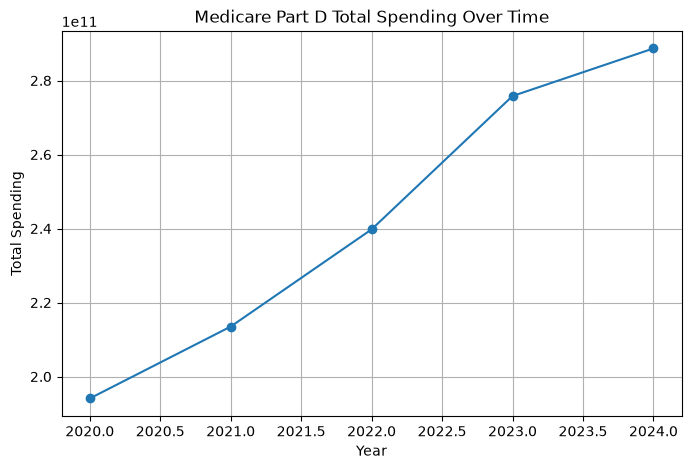

In [81]:
import matplotlib.pyplot as plt

# Create a spending trend chart
plt.figure(figsize=(8, 5))

plt.plot(
    spending_trend["Year"],
    spending_trend["Total Spending"],
    marker="o"
)

plt.title("Medicare Part D Total Spending Over Time")
plt.xlabel("Year")
plt.ylabel("Total Spending")

# Show years as full numbers

plt.grid(True)
plt.show()

### Examine Claims Over Time

Total claims are used as a measure of drug utilization. Claims are compared across the available years to examine changes in utilization.

In [82]:
# Calculate total claims for each year
yearly_claims = []

for year in years:
    column = "Tot_Clms_" + str(year)

    if column in drug_data.columns:
        yearly_claims.append(
            drug_data[column].sum()
        )

# Create a table
claims_trend = pd.DataFrame({
    "Year": years,
    "Total Claims": yearly_claims
})

claims_trend

,Year,Total Claims
0,2020,1.454422e+09
1,2021,1.483268e+09
2,2022,1.539211e+09
3,2023,1.616689e+09
4,2024,1.711657e+09


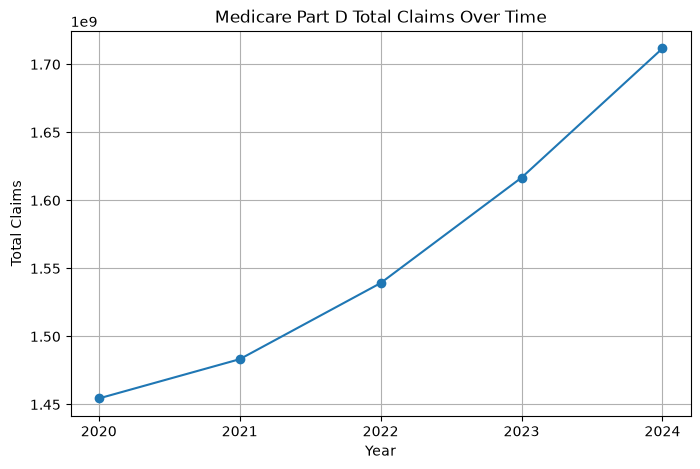

In [83]:
# Create a claims trend chart
plt.figure(figsize=(8, 5))

plt.plot(
    claims_trend["Year"],
    claims_trend["Total Claims"],
    marker="o"
)

plt.title("Medicare Part D Total Claims Over Time")
plt.xlabel("Year")
plt.ylabel("Total Claims")
plt.grid(True)

# Show years as full numbers
plt.xticks(years)

plt.show()

### Examine Dosage Units Over Time

Dosage units provide another measure of drug utilization. Total dosage units are compared across the available years.

In [84]:
# Calculate total dosage units for each year
yearly_dosage = []

for year in years:
    column = "Tot_Dsg_Unts_" + str(year)

    if column in drug_data.columns:
        yearly_dosage.append(
            drug_data[column].sum()
        )

# Create a table
dosage_trend = pd.DataFrame({
    "Year": years,
    "Total Dosage Units": yearly_dosage
})

dosage_trend

,Year,Total Dosage Units
0,2020,1.108248e+11
1,2021,1.133941e+11
2,2022,1.194264e+11
3,2023,1.246605e+11
4,2024,1.312123e+11


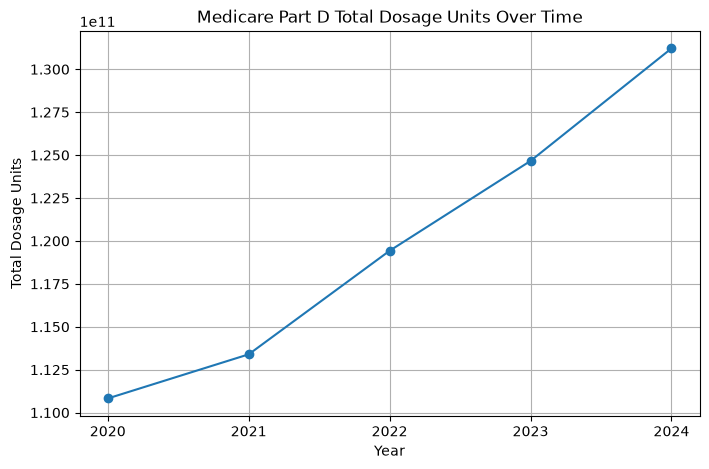

In [85]:
# Create a dosage units trend chart
plt.figure(figsize=(8, 5))

plt.plot(
    dosage_trend["Year"],
    dosage_trend["Total Dosage Units"],
    marker="o"
)

plt.title("Medicare Part D Total Dosage Units Over Time")
plt.xlabel("Year")
plt.ylabel("Total Dosage Units")
plt.grid(True)

# Show years as full numbers
plt.xticks(years)

plt.show()

### Identify Drugs With Large Increases or Decreases

Drug spending in the first available year is compared with spending in the most recent year.

Both the dollar change and percentage change are calculated to identify drugs with large increases or decreases in spending.

In [86]:
# Identify first and latest years
first_year = min(years)
latest_year = max(years)

print("First year:", first_year)
print("Latest year:", latest_year)

First year: 2020
Latest year: 2024


In [87]:
# Create spending column names
first_spending = "Tot_Spndng_" + str(first_year)
latest_spending = "Tot_Spndng_" + str(latest_year)

# Calculate dollar change
drug_data["Spending_Change"] = (
    drug_data[latest_spending]
    - drug_data[first_spending]
)

# Calculate percentage change
drug_data["Spending_Percent_Change"] = (
    drug_data["Spending_Change"]
    / drug_data[first_spending]
) * 100

In [88]:
# Find the 10 largest spending increases
largest_increases = drug_data.nlargest(
    10,
    "Spending_Change"
)

largest_increases[
    [
        "Brnd_Name",
        "Gnrc_Name",
        first_spending,
        latest_spending,
        "Spending_Change",
        "Spending_Percent_Change"
    ]
]

,Brnd_Name,Gnrc_Name,Tot_Spndng_2020,Tot_Spndng_2024,Spending_Change,Spending_Percent_Change
2346,Ozempic,Semaglutide,1.455812e+09,1.297030e+10,1.151448e+10,790.931931
1007,Eliquis,Apixaban,9.936070e+09,2.077493e+10,1.083886e+10,109.085983
1601,Jardiance,Empagliflozin,2.376166e+09,1.143600e+10,9.059831e+09,381.279339
1163,Farxiga,Dapagliflozin Propanediol,7.367876e+08,5.290549e+09,4.553761e+09,618.056225
3149,Trelegy Ellipta,Fluticasone/Umeclidin/Vilanter,1.487802e+09,5.294402e+09,3.806599e+09,255.853849
1051,Entresto,Sacubitril/Valsartan,1.203044e+09,4.020322e+09,2.817278e+09,234.179234
3443,Vyndamax,Tafamidis,2.532675e+08,2.830812e+09,2.577544e+09,1017.716013
2913,Stelara*,Ustekinumab,1.106356e+09,3.378017e+09,2.271661e+09,205.328178
3219,Trulicity,Dulaglutide,3.284873e+09,5.454135e+09,2.169262e+09,66.037914
1423,Humira(Cf) Pen,Adalimumab,2.169430e+09,4.328699e+09,2.159268e+09,99.531583


In [89]:
# Find the 10 largest spending decreases
largest_decreases = drug_data.nsmallest(
    10,
    "Spending_Change"
)

largest_decreases[
    [
        "Brnd_Name",
        "Gnrc_Name",
        first_spending,
        latest_spending,
        "Spending_Change",
        "Spending_Percent_Change"
    ]
]

,Brnd_Name,Gnrc_Name,Tot_Spndng_2020,Tot_Spndng_2024,Spending_Change,Spending_Percent_Change
1714,Lantus Solostar,"Insulin Glargine,Hum.Rec.Anlog",2.663360e+09,6.991325e+08,-1.964228e+09,-73.749984
1744,Levemir Flextouch,Insulin Detemir,1.554791e+09,9.567693e+05,-1.553835e+09,-99.938463
2201,Novolog Flexpen,Insulin Aspart,1.844084e+09,3.189135e+08,-1.525171e+09,-82.706130
2968,Symbicort,Budesonide/Formoterol Fumarate,1.979984e+09,5.978058e+08,-1.382178e+09,-69.807540
3387,Victoza 3-Pak,Liraglutide,1.545815e+09,2.030631e+08,-1.342752e+09,-86.863694
1721,Latuda,Lurasidone HCl,1.316735e+09,3.964292e+07,-1.277092e+09,-96.989302
2684,Revlimid,Lenalidomide,5.356050e+09,4.179511e+09,-1.176539e+09,-21.966537
71,Advair Diskus,Fluticasone Propion/Salmeterol,1.160475e+09,7.121298e+07,-1.089262e+09,-93.863463
1713,Lantus,"Insulin Glargine,Hum.Rec.Anlog",1.055723e+09,1.398941e+08,-9.158285e+08,-86.748976
3025,Tecfidera,Dimethyl Fumarate,1.054985e+09,1.628423e+08,-8.921423e+08,-84.564482


### Top Drugs by Spending

The drugs with the highest total spending in the most recent year are identified and compared.

In [90]:
# Find the top 10 drugs by spending
top_drugs = drug_data.nlargest(
    10,
    latest_spending
)

top_drugs[
    [
        "Brnd_Name",
        "Gnrc_Name",
        latest_spending
    ]
]

,Brnd_Name,Gnrc_Name,Tot_Spndng_2024
1007,Eliquis,Apixaban,2.077493e+10
2346,Ozempic,Semaglutide,1.297030e+10
1601,Jardiance,Empagliflozin,1.143600e+10
2038,Mounjaro,Tirzepatide,6.336943e+09
3478,Xarelto,Rivaroxaban,6.232232e+09
3219,Trulicity,Dulaglutide,5.454135e+09
3149,Trelegy Ellipta,Fluticasone/Umeclidin/Vilanter,5.294402e+09
1163,Farxiga,Dapagliflozin Propanediol,5.290549e+09
1423,Humira(Cf) Pen,Adalimumab,4.328699e+09
2684,Revlimid,Lenalidomide,4.179511e+09


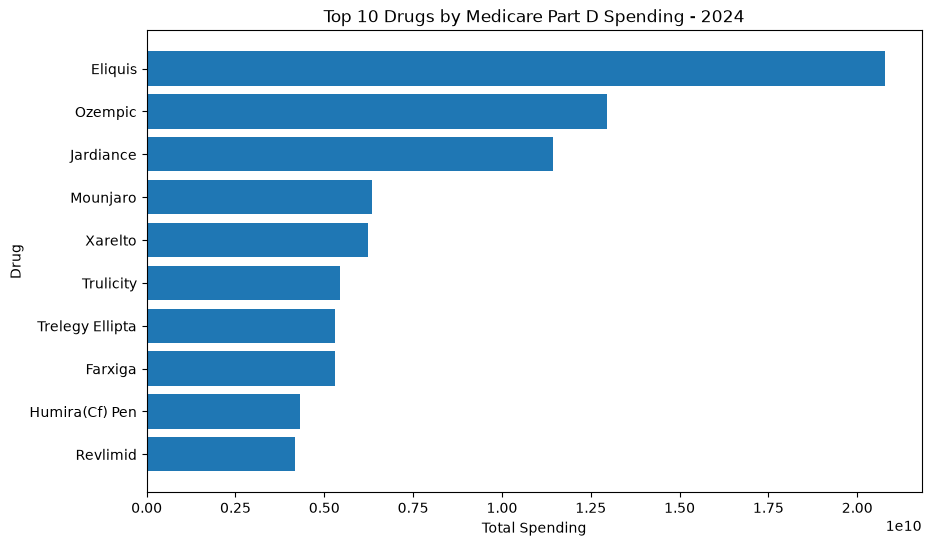

In [91]:
# Create a bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_drugs["Brnd_Name"],
    top_drugs[latest_spending]
)

plt.title(
    "Top 10 Drugs by Medicare Part D Spending - "
    + str(latest_year)
)

plt.xlabel("Total Spending")
plt.ylabel("Drug")

plt.gca().invert_yaxis()

plt.show()

### Top 10 Drugs: Spending Across All Years

The top 10 drugs are identified based on their total Medicare Part D spending across all available years.

A line chart is used to compare how spending for these drugs changed over time.

In [92]:
# Create a list of spending columns
spending_columns = [
    "Tot_Spndng_" + str(year)
    for year in years
    if "Tot_Spndng_" + str(year) in drug_data.columns
]

# Calculate total spending across all years
drug_data["Total_Spending_All_Years"] = (
    drug_data[spending_columns].sum(axis=1)
)

# Find the top 10 drugs
top_10_all_years = drug_data.nlargest(
    10,
    "Total_Spending_All_Years"
)

# Display the top 10
top_10_all_years[
    [
        "Brnd_Name",
        "Gnrc_Name",
        "Total_Spending_All_Years"
    ]
]

,Brnd_Name,Gnrc_Name,Total_Spending_All_Years
1007,Eliquis,Apixaban,7.677941e+10
1601,Jardiance,Empagliflozin,3.223959e+10
2346,Ozempic,Semaglutide,3.087001e+10
3478,Xarelto,Rivaroxaban,2.824102e+10
3219,Trulicity,Dulaglutide,2.703033e+10
2684,Revlimid,Lenalidomide,2.522397e+10
1600,Januvia,Sitagliptin Phosphate,1.992131e+10
1423,Humira(Cf) Pen,Adalimumab,1.751929e+10
3149,Trelegy Ellipta,Fluticasone/Umeclidin/Vilanter,1.697135e+10
1163,Farxiga,Dapagliflozin Propanediol,1.437565e+10


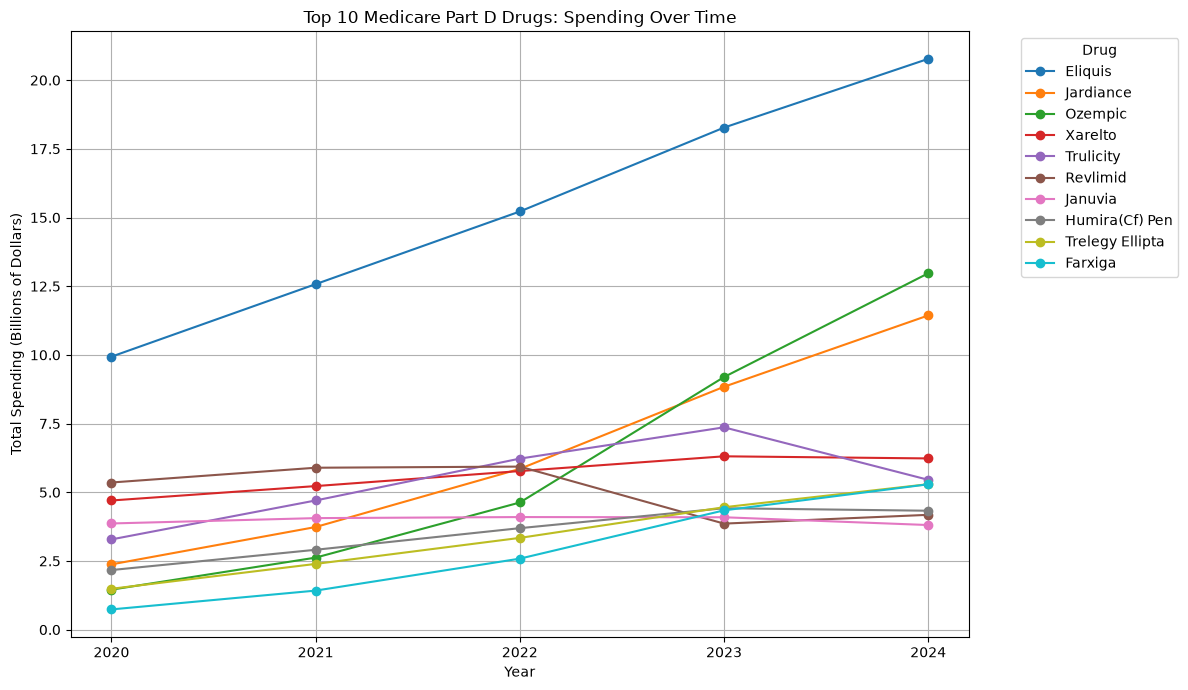

In [93]:
# Create a line graph using billions of dollars
plt.figure(figsize=(12, 7))

for index, row in top_10_all_years.iterrows():

    spending_values = [
        row["Tot_Spndng_" + str(year)] / 1_000_000_000
        for year in years
    ]

    plt.plot(
        years,
        spending_values,
        marker="o",
        label=row["Brnd_Name"]
    )

plt.title("Top 10 Medicare Part D Drugs: Spending Over Time")
plt.xlabel("Year")
plt.ylabel("Total Spending (Billions of Dollars)")

# Display full years
plt.xticks(years)

plt.legend(
    title="Drug",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()

plt.show()

## Spending and Claims Relationship

A scatter plot is used to examine the relationship between total claims and total spending.

This helps determine whether drugs with higher utilization also tend to have higher Medicare Part D spending and can help identify drugs with unusually high spending.

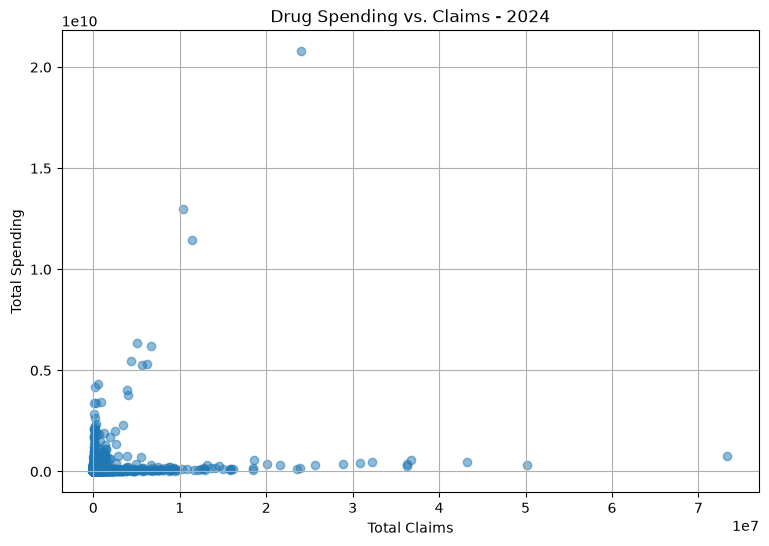

In [94]:
# Use the latest year
spending_col = "Tot_Spndng_" + str(latest_year)
claims_col = "Tot_Clms_" + str(latest_year)

plt.figure(figsize=(9, 6))

plt.scatter(
    drug_data[claims_col],
    drug_data[spending_col],
    alpha=0.5
)

plt.title(
    "Drug Spending vs. Claims - "
    + str(latest_year)
)

plt.xlabel("Total Claims")
plt.ylabel("Total Spending")

plt.grid(True)
plt.show()

### Spending per Claim Over Time

Spending per claim is calculated by dividing total spending by total claims for each year.

This provides additional information about whether spending is changing relative to the number of claims.

In [95]:
spending_per_claim = []

for year in years:

    spending_col = "Tot_Spndng_" + str(year)
    claims_col = "Tot_Clms_" + str(year)

    total_spending = drug_data[spending_col].sum()
    total_claims = drug_data[claims_col].sum()

    average = total_spending / total_claims

    spending_per_claim.append(average)

spending_per_claim_trend = pd.DataFrame({
    "Year": years,
    "Spending Per Claim": spending_per_claim
})

spending_per_claim_trend

,Year,Spending Per Claim
0,2020,133.449588
1,2021,143.947902
2,2022,155.780588
3,2023,170.601144
4,2024,168.648181


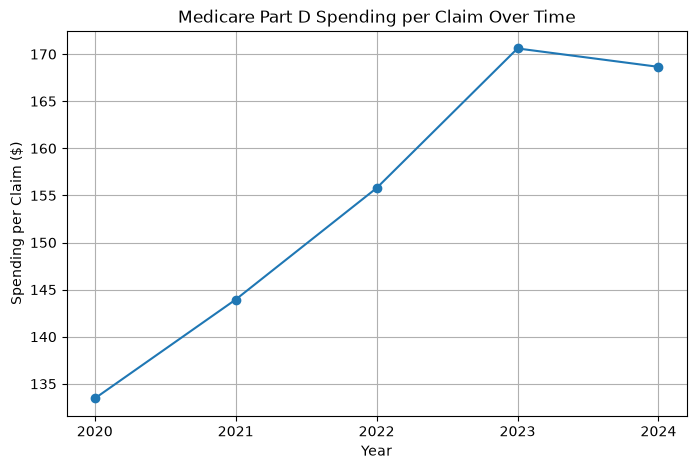

In [96]:
plt.figure(figsize=(8, 5))

plt.plot(
    spending_per_claim_trend["Year"],
    spending_per_claim_trend["Spending Per Claim"],
    marker="o"
)

plt.title("Medicare Part D Spending per Claim Over Time")
plt.xlabel("Year")
plt.ylabel("Spending per Claim ($)")

# Full year numbers
plt.xticks(years)

plt.grid(True)
plt.show()

### Drugs With the Largest Spending Increases

A bar chart is used to compare the drugs with the largest increases in total spending between the first and most recent years.

This makes it easier to identify which drugs experienced the largest dollar increases in Medicare Part D spending.

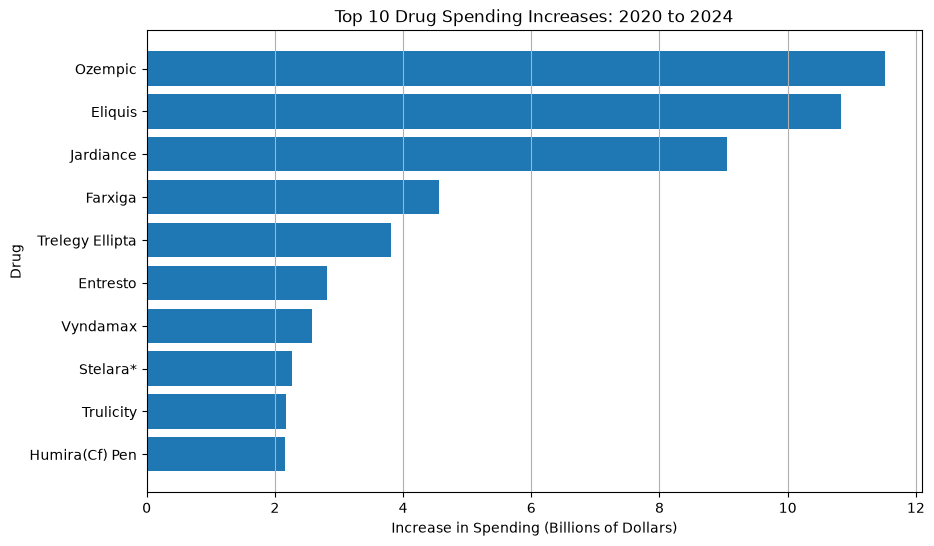

In [97]:
# Top 10 largest spending increases
top_changes = drug_data.nlargest(
    10,
    "Spending_Change"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_changes["Brnd_Name"],
    top_changes["Spending_Change"] / 1_000_000_000
)

plt.title(
    "Top 10 Drug Spending Increases: "
    + str(first_year)
    + " to "
    + str(latest_year)
)

plt.xlabel("Increase in Spending (Billions of Dollars)")
plt.ylabel("Drug")

plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

### Week 3 Summary

During Week 3, summary statistics were calculated to examine the numeric variables in the dataset.

Charts were created to examine changes in Medicare Part D spending, claims, and dosage units over time. Drug spending in the first available year was compared with spending in the most recent year to identify drugs with large increases and decreases.

For drug-level analysis, the Overall records were used so that each drug was represented once and values were not double counted. Manufacturer-specific records remained in the cleaned dataset.

The Week 3 analysis provides a better understanding of the main spending and utilization trends and prepares the data for Week 4.